# Solving a Retirement Choice Model with FUES-EGM

**Paper**: Dobrescu and Shanker (2026), *A Fast Upper Envelope Scan Method for Discrete-Continuous Dynamic Programming*

This notebook solves the discrete retirement choice model from [Iskhakov et al. (2017)](https://onlinelibrary.wiley.com/doi/abs/10.3982/QE643) using the FUES upper-envelope method. 
The emphasis is on the geometry and performance of the upper-envelope step rather than on the general mechanics of solving the model, so we rely on pre-existing model files and solver routines.

> **Note on the model files**
>
> This notebook loads the retirement model from a set of declarative YAML files. In this language, a **stage** is just one self-contained part of the dynamic problem, such as the worker's consumption choice, the retiree's consumption choice, or the labour-market decision. A full period is built by linking these stages together in sequence.
>
> The YAML format used here is called **dolo-plus**. It is simply a structured, machine-readable way of writing down the model's states, controls, transitions, and Bellman objects. You do **not** need to learn that syntax to follow this notebook. The point of this repository is not to teach dolo-plus or Bellman-DDSL terminology; it is to understand FUES. We use the YAML files only to load the model cleanly, so that we can focus on the endogenous-grid value correspondence, the suboptimal points created by the discrete retirement choice, and the performance of the competing upper-envelope methods.

We proceed step by step:

1. **Model** — state the Bellman equation and Euler equations
2. **Load stages** — read the dolo-plus YAML stage declarations
3. **Solve** — run the canonical pipeline (`solve_nest`)
4. **Inspect EGM grids** — see the suboptimal points and how FUES removes them
5. **Comparison** — FUES vs MSS vs RFC vs LTM
6. **Scaling** — upper envelope time vs grid size

**Upper-envelope methods compared:**

| This notebook | Paper name | Reference |
|---------------|------------|-----------|
| FUES | FUES | Dobrescu & Shanker (2026) |
| MSS | MSS (monotone segment selection) | Iskhakov et al. (2017), via [HARK](https://econ-ark.org) |
| LTM | LTM (local triangulation) | Druedahl (2021), via [ConSav](https://github.com/NumEconCopenhagen/ConsumptionSaving) |
| RFC | RFC (rooftop cut) | Dobrescu & Shanker (2024) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time, sys, os, yaml, tempfile
from pathlib import Path
from IPython.display import Image, Markdown, display

# ── Repo paths (robust: walk up until we find pyproject.toml) ──
_here = Path(os.path.abspath('')).resolve()
REPO = _here
for _ in range(10):
    if (REPO / 'pyproject.toml').exists():
        break
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'src'))

SYNTAX_DIR = REPO / 'examples' / 'retirement' / 'syntax'

# ── Imports ──
from examples.retirement.solve import solve_nest
from examples.retirement.outputs import (
    get_policy, get_timing, get_solution_at_age,
    euler, consumption_deviation,
    # Notebook plotters (consistent Nord style)
    setup_nb_style,
    nb_plot_egrids, nb_plot_egm_interactive,
    nb_plot_cons_ages, nb_plot_scaling,
)

# ── Apply notebook style globally ──
setup_nb_style()
print(f'REPO: {REPO}')

REPO: /Users/akshayshanker/Research/Repos/FUES2026/FUES


---

## 1. Model

An agent lives for $T$ periods. Each period they choose consumption $c_t$ and whether to work ($d_{t+1}=1$) or permanently retire ($d_{t+1}=0$). Working pays wage $y$ but costs utility $\delta$. Retirement is absorbing.

**Budget constraint:**

$$a_{t+1} = (1+r)a_t + d_t y - c_t$$

**Worker's Bellman equation** (for $d_t = 1$):

$$V_t^1(a) = \max_{c,\, d_{t+1} \in \{0,1\}} \Big\{ \log(c) - d_{t+1}\delta + \beta V_{t+1}^{d_{t+1}}(a') \Big\}$$

**Retiree's Bellman equation** (for $d_t = 0$):

$$V_t^0(a) = \max_c \Big\{ \log(c) + \beta V_t^0(a') \Big\}, \quad a' = (1+r)a - c$$

**Terminal condition:** $V_T^d(a) = \log((1+r)a + dy)$.

The key difficulty: $V_{t+1}^1$ is **not concave** because it is the upper envelope of concave functions, each conditional on a different sequence of future discrete choices.

In [2]:
# ── Display the stage YAML declarations ──
stage_names = ['work_cons', 'retire_cons', 'labour_mkt_decision']

for name in stage_names:
    path = SYNTAX_DIR / 'stages' / name / f'{name}.yaml'
    print(f'\n{"=" * 60}')
    print(f'  {name}  ({path.relative_to(REPO)})')
    print(f'{"=" * 60}')
    print(path.read_text())


  work_cons  (examples/retirement/syntax/stages/work_cons/work_cons.yaml)
name: WorkerConsumption
symbols:
  spaces:
    Xa: "@def R+"
  prestate:
    a: "@in Xa"           # assets (from branching stage)
  states:
    w: "@in Xa"           # cash-on-hand = (1+r)*a + y
  poststates:
    b: "@in Xa"           # end-of-period assets
  controls:
    c: "@in R+"
  exogenous: {}
  values:
    V[>]: "@in [-inf, inf)"
    V[<]: "@in [-inf, inf)"
    V: "@in [-inf, inf)"
  values_marginal:
    dV[>]: "@in R+"
    dV[<]: "@in R+"
    dV: "@in R+"
  parameters: [beta, r, y]
  settings: [n_w, w_min, w_max, m_bar]
equations:
  arvl_to_dcsn_transition: |
    w = (1 + r) * a + y
  dcsn_to_cntn_transition: |
    b = w - c
  cntn_to_dcsn_mover:
    Bellman: |
      V = max_c{log(c) + beta * V[>]}
    InvEuler: |
      c[>] = (beta * dV[>])^(-1)
    cntn_to_dcsn_transition: |
      w[>] = b + c[>]
    MarginalBellman: |
      dV = 1/c
  dcsn_to_arvl_mover:
    Bellman: |
      V[<] = V
    MarginalBel

## 2b. Calibration and settings (single source of truth)

These YAML files are consumed by the **calibrate** and **configure** functors of the dolo-plus pipeline. No parameters are hard-coded in Python.

In [3]:
# ── Display calibration and settings ──
for fname in ['calibration.yaml', 'settings.yaml']:
    path = SYNTAX_DIR / fname
    print(f'\n--- {fname} ---')
    print(path.read_text())


--- calibration.yaml ---
# Economic parameters (consumed by calibrate functor)
# Single source of truth — no Python-side defaults.
calibration:
  r: 0.02              # interest rate
  beta: 0.96           # discount factor
  delta: 1           # utility cost of working
  y: 20                # wage income for workers
  b: 1.0e-10           # borrowing constraint (near zero)
  smooth_sigma: 0      # logit smoothing (0 = hard max)


--- settings.yaml ---
# Numerical / structural settings (consumed by configure functor)
# Single source of truth — no Python-side defaults.
settings:
  # Lifecycle
  T: 20                  # number of periods
  # Asset grid (used by RetirementModel to construct arrival grid)
  grid_size: 3000        # number of asset grid points
  grid_max_A: 500        # upper bound for asset grid
  # Worker grids (work branch — used by dolo-plus configure)
  n_w: 300               # grid points for worker cash-on-hand
  w_min: 1.0e-10         # borrowing constraint (near 

---

## 3. Solve via the Canonical Pipeline

`solve_nest` is the single entry point. It loads the YAML files, applies the three functors (methodize, configure, calibrate) to each stage, builds the model, and runs backward induction.

Each period solves three stages in reverse topological order:
1. **`retire_cons`** — retiree EGM (concave, no upper envelope needed)
2. **`work_cons`** — worker EGM + upper envelope (FUES/MSS/RFC/LTM)
3. **`labour_mkt_decision`** — $\max(V^{\text{work}}, V^{\text{retire}})$ pointwise

In [4]:
# ── Warmup (JIT compile) then timed solve ──
# Solve for 50 periods (longer horizon shows more kinks)
solve_nest(SYNTAX_DIR, method='FUES', config_overrides={'T': 50})

nest, model, stage_ops = solve_nest(
    SYNTAX_DIR, method='FUES', config_overrides={'T': 50})

print(f'Model: T={model.T}, grid_size={model.grid_size}, '
      f'beta={model.beta}, delta={model.delta}, y={model.y}')
print(f'Euler error: {euler(model, get_policy(nest, "c")):.6f}')

Model: T=50, grid_size=3000, beta=0.96, delta=1.0, y=20.0
Euler error: -1.628838


---

## 4. Inspect the EGM Grid

`plot_egrids` (from `outputs/plots.py`) shows the raw vs refined EGM grids at a given age:
- **Left**: value correspondence — red circles are raw EGM, blue crosses are FUES-selected, green stars are crossing points.
- **Right**: asset policy — same colour coding.

The interactive plotly version below lets you **zoom** (drag a box) and **pan** (shift-drag) to inspect crossing point regions. Double-click to reset.

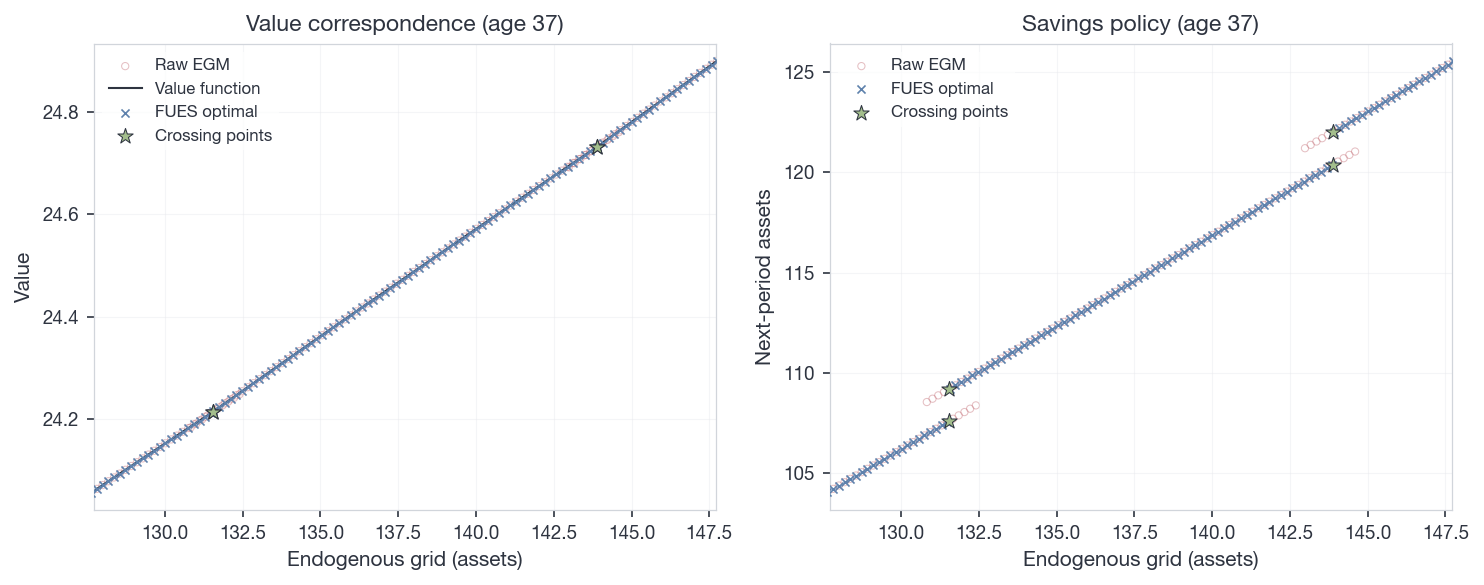

In [5]:
# ── EGM grid with FUES refinement (static, notebook style) ──
plot_age = 37
fig = nb_plot_egrids(nest, model, age=plot_age)
plt.show()

In [6]:
# ── Interactive EGM grid plot (auto-centered on crossings, auto y-range) ──
from examples.retirement.outputs import nb_plot_egm_interactive

fig = nb_plot_egm_interactive(nest, model, age=plot_age, pad=10)
fig.show()

---

## 5. Consumption Policy Across Ages

`plot_cons_pol` shows consumption as a function of assets at three ages. The discontinuous jumps correspond to the retirement decision — agents with wealth above the threshold retire.

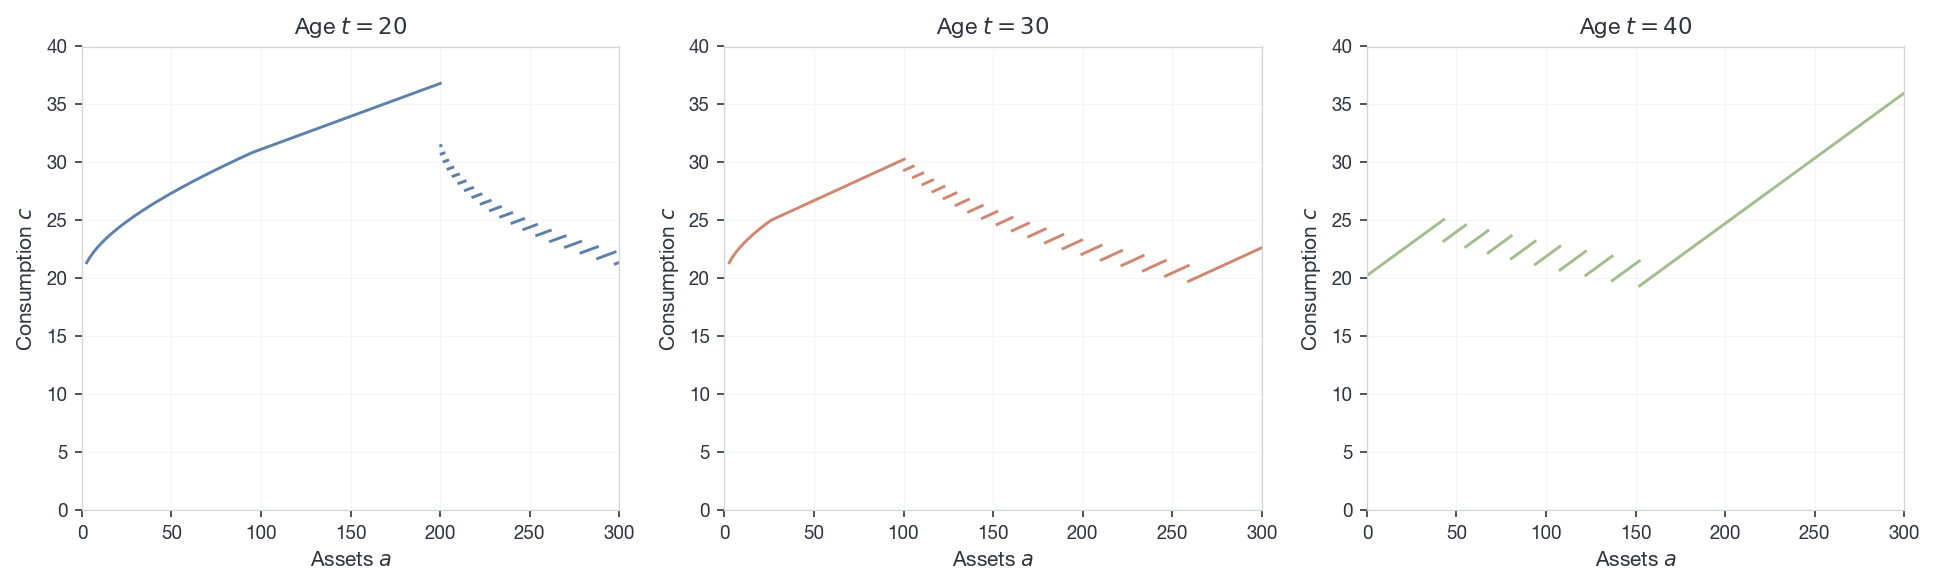

In [7]:
# ── Consumption policy at multiple ages ──
from examples.retirement.outputs import nb_plot_cons_ages

fig = nb_plot_cons_ages(nest, model, ages=(20, 30, 40))
plt.show()

---

## 6. Method Comparison

At this calibration, all four upper-envelope methods deliver essentially the same solution quality: the reported Euler errors are extremely close, and the small differences are numerical rather than economically meaningful. The substantive comparison is therefore computational.

For the baseline grid shown here (`grid_size = 3000`), FUES takes `0.209 ms` for the upper-envelope step and `0.322 ms` in total, while MSS takes `5.417 ms` and `5.543 ms`, RFC takes `4.817 ms` and `4.959 ms`, and LTM takes `5.822 ms` and `5.961 ms`. In this benchmark, the main distinction across methods is not accuracy, but how much time is required to recover the upper envelope.

In [8]:
# ── Solve with all four methods (T=50) ──
methods = ['FUES', 'DCEGM', 'RFC', 'CONSAV']
# Display labels (API uses DCEGM/CONSAV internally)
_DISPLAY = {'FUES': 'FUES', 'DCEGM': 'MSS', 'RFC': 'RFC', 'CONSAV': 'LTM'}
results = {}

for method in methods:
    solve_nest(SYNTAX_DIR, method=method, config_overrides={'T': 50})  # warmup
    nest_m, model_m, _ = solve_nest(
        SYNTAX_DIR, method=method, config_overrides={'T': 50})
    c_pol = get_policy(nest_m, 'c')
    ue_t, solve_t = get_timing(nest_m)
    results[method] = {
        'euler': euler(model_m, c_pol),
        'ue_ms': ue_t * 1000,
        'total_ms': solve_t * 1000,
    }

# ── Results table ──
print(f'{"Method":>8s} | {"Euler Error":>12s} | {"UE (ms)":>10s} | {"Total (ms)":>12s}')
print('-' * 50)
for m in methods:
    r = results[m]
    print(f'{_DISPLAY[m]:>8s} | {r["euler"]:>12.6f} | {r["ue_ms"]:>10.3f} | {r["total_ms"]:>12.3f}')

  Method |  Euler Error |    UE (ms) |   Total (ms)
--------------------------------------------------
    FUES |    -1.628838 |      0.175 |        0.272
     MSS |    -1.628767 |      5.269 |        5.376
     RFC |    -1.628718 |      5.151 |        5.305
     LTM |    -1.628846 |      5.885 |        6.022


---

## 7. Scaling: Upper Envelope Time vs Grid Size

The scaling exercise sharpens the same message. We sweep grid sizes from 1,000 to 12,000 and compare upper-envelope time across methods. FUES remains the fastest method throughout, with a much smaller constant factor than the alternatives.

MSS and RFC both scale approximately linearly in this experiment and stay relatively close to one another. LTM is competitive only on the very smallest grids, but its cost rises much more quickly and it is overtaken by the time we reach the medium-sized grids used in the main comparison.

In [9]:
# ── Scaling sweep (equal steps for visual linearity check) ──
import gc

grid_sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000]
scaling = {m: [] for m in methods}

for gs in grid_sizes:
    for method in methods:
        n, _, _ = solve_nest(
            SYNTAX_DIR, method=method,
            config_overrides={'grid_size': gs, 'T': 50})
        ue, _ = get_timing(n)
        scaling[method].append(ue * 1000)
        del n
    gc.collect()
    print(f'grid_size={gs:>6d}  '
          + '  '.join(f'{m}: {scaling[m][-1]:.2f}ms' for m in methods))

grid_size=  1000  FUES: 0.13ms  DCEGM: 1.88ms  RFC: 1.72ms  CONSAV: 0.69ms
grid_size=  2000  FUES: 0.17ms  DCEGM: 3.83ms  RFC: 3.26ms  CONSAV: 2.64ms
grid_size=  3000  FUES: 0.23ms  DCEGM: 5.49ms  RFC: 4.99ms  CONSAV: 5.88ms
grid_size=  4000  FUES: 0.25ms  DCEGM: 7.19ms  RFC: 6.86ms  CONSAV: 10.50ms
grid_size=  5000  FUES: 0.42ms  DCEGM: 9.25ms  RFC: 8.97ms  CONSAV: 16.38ms
grid_size=  6000  FUES: 0.40ms  DCEGM: 11.02ms  RFC: 10.48ms  CONSAV: 23.48ms
grid_size=  7000  FUES: 0.58ms  DCEGM: 14.48ms  RFC: 13.50ms  CONSAV: 32.36ms
grid_size=  8000  FUES: 0.48ms  DCEGM: 14.33ms  RFC: 14.55ms  CONSAV: 41.33ms
grid_size=  9000  FUES: 0.52ms  DCEGM: 16.00ms  RFC: 16.04ms  CONSAV: 51.76ms
grid_size= 10000  FUES: 0.55ms  DCEGM: 19.60ms  RFC: 19.18ms  CONSAV: 67.03ms
grid_size= 11000  FUES: 0.74ms  DCEGM: 20.54ms  RFC: 19.18ms  CONSAV: 78.09ms
grid_size= 12000  FUES: 0.67ms  DCEGM: 22.31ms  RFC: 22.37ms  CONSAV: 92.96ms
grid_size= 13000  FUES: 0.78ms  DCEGM: 25.53ms  RFC: 25.97ms  CONSAV: 114.58m

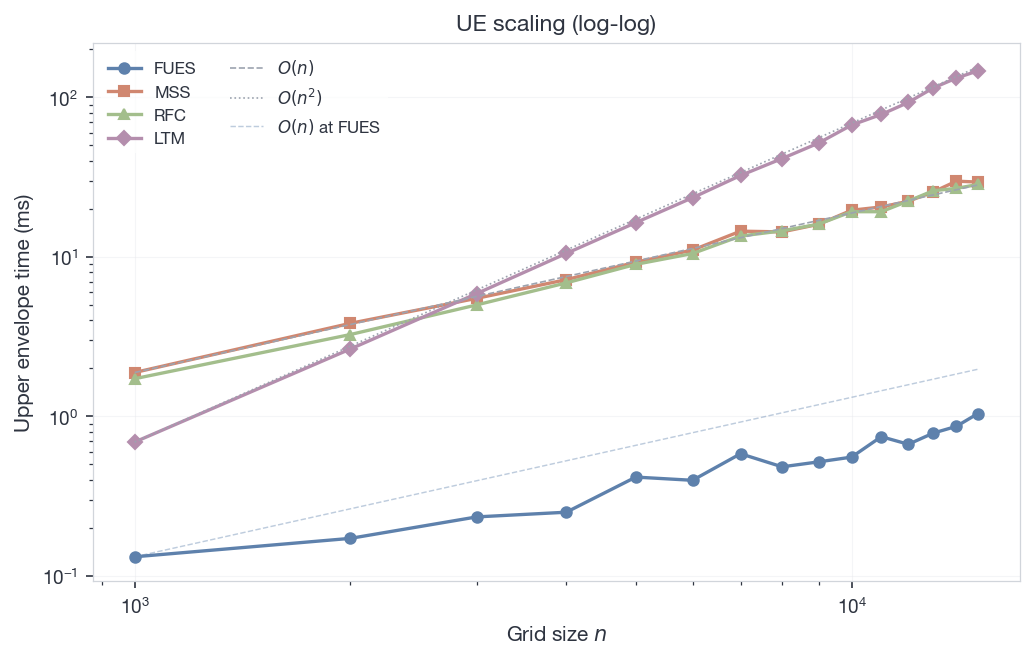

In [10]:
# ── Scaling plot ──
from examples.retirement.outputs import nb_plot_scaling

fig = nb_plot_scaling(grid_sizes, scaling, methods=methods)
plt.show()

checkpoints = [1000, 3000, 12000]
idx_by_grid = {gs: i for i, gs in enumerate(grid_sizes)}

lines = [
    "**Notebook scaling observations (live):**",
    "",
    "The table below reports the upper-envelope time ratio `other method / FUES`, so larger numbers mean a larger speed advantage for FUES.",
    "",
    "| Grid size | MSS / FUES | RFC / FUES | LTM / FUES |",
    "|-----------|------------|------------|------------|",
]

for gs in checkpoints:
    i = idx_by_grid[gs]
    fues_t = scaling['FUES'][i]
    mss_ratio = scaling['DCEGM'][i] / fues_t
    rfc_ratio = scaling['RFC'][i] / fues_t
    ltm_ratio = scaling['CONSAV'][i] / fues_t
    lines.append(f"| {gs:,} | {mss_ratio:.1f}x | {rfc_ratio:.1f}x | {ltm_ratio:.1f}x |")

lines.extend([
    "",
    "MSS and RFC remain close to one another across the sweep, while LTM becomes much more expensive as the grid grows.",
])

display(Markdown("\n".join(lines)))

Laptop timings can be noisy due to thermal throttling, OS scheduling, and background processes. The PBS cluster results below provide cleaner measurements on dedicated hardware.

---

## 8. PBS Cluster Timings (Gadi)

Compare the notebook scaling sweep (above) with timings from a PBS batch run on NCI Gadi.
The table below is parsed from a timing markdown file produced by `run.py --run-timings`.
We average UE time across all $\delta$ values for each grid size and method.

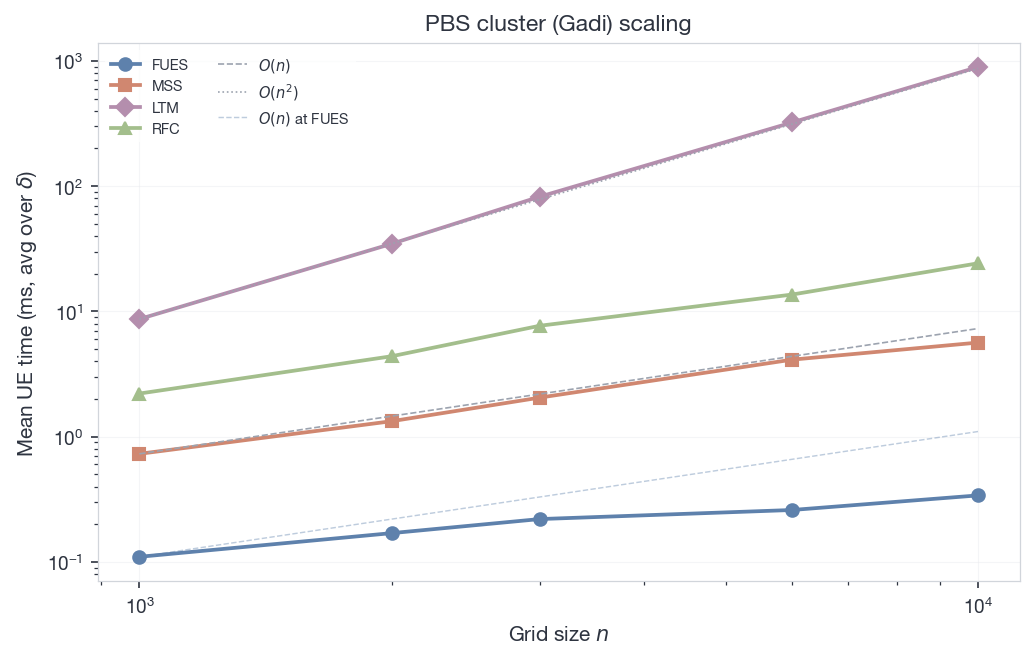

In [11]:
# ── PBS cluster timings ──
from nb_pbs import plot_pbs_scaling

timing_path = REPO / 'examples' / 'retirement' / 'results' / \
    'retirement_20260305_125534' / 'retirement_timing.md'

fig = plot_pbs_scaling(timing_path)
plt.show()


---

## Summary

- The retirement model has a **discrete-continuous** structure: the agent jointly chooses consumption (continuous) and work/retire (discrete).
- EGM inverts the Euler equation to avoid numerical optimization, but produces **suboptimal points** where future discrete choices change.
- **FUES** identifies and removes these suboptimal points via a targeted secant scan, checking for concave right turns that coincide with policy jumps.
- In this benchmark, all four upper-envelope methods (FUES, MSS, RFC, LTM) deliver essentially the same solution quality; the Euler-error differences are numerically tiny.
- The practical difference is speed: FUES is the fastest method throughout the experiment, MSS and RFC remain close to one another, and LTM becomes increasingly expensive as the grid grows.

For models where policy monotonicity fails (housing, durables, non-linear taxes), FUES is the only EGM-based method in this comparison that continues to work without imposing monotonicity. See the [paper](https://github.com/akshayshanker/FUES) for formal results and additional applications.